In [1]:
import pandas as pd

df = pd.read_csv(r"d:\day1\train.csv")

print("=" * 40)
print("  KIỂM TRA CẤU TRÚC DỮ LIỆU")
print("=" * 40)
print(f"Số dòng (samples) : {df.shape[0]}")
print(f"Số cột (features) : {df.shape[1]}")
print(f"\nDanh sách cột     : {list(df.columns)}")
print("\n--- Kiểu dữ liệu từng cột ---")
print(df.dtypes)
print("\n--- Thông tin tổng quan ---")
df.info()


  KIỂM TRA CẤU TRÚC DỮ LIỆU
Số dòng (samples) : 20972
Số cột (features) : 9

Danh sách cột     : ['ID', 'TITLE', 'ABSTRACT', 'Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

--- Kiểu dữ liệu từng cột ---
ID                      int64
TITLE                     str
ABSTRACT                  str
Computer Science        int64
Physics                 int64
Mathematics             int64
Statistics              int64
Quantitative Biology    int64
Quantitative Finance    int64
dtype: object

--- Thông tin tổng quan ---
<class 'pandas.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    20972 non-null  int64
 1   TITLE                 20972 non-null  str  
 2   ABSTRACT              20972 non-null  str  
 3   Computer Science      20972 non-null  int64
 4   Physics               20972

In [2]:
print("=" * 40)
print("  KIỂM TRA DỮ LIỆU THIẾU (NULL/NaN)")
print("=" * 40)
missing = df.isnull().sum()
print(missing)
print(f"\nTổng số ô bị thiếu: {missing.sum()}")

print("\n" + "=" * 40)
print("  KIỂM TRA DỮ LIỆU TRÙNG LẶP")
print("=" * 40)

dup_title    = df["TITLE"].duplicated().sum()
dup_abstract = df["ABSTRACT"].duplicated().sum()
dup_both     = df.duplicated(subset=["TITLE", "ABSTRACT"]).sum()

print(f"Số TITLE trùng lặp           : {dup_title}")
print(f"Số ABSTRACT trùng lặp        : {dup_abstract}")
print(f"Số dòng trùng cả TITLE+ABSTRACT: {dup_both}")

if dup_both > 0:
    print("\n--- Ví dụ các dòng trùng lặp ---")
    mask = df.duplicated(subset=["TITLE", "ABSTRACT"], keep=False)
    print(df[mask][["ID", "TITLE"]].head(6).to_string(index=False))
else:
    print("\n=> Không có dòng nào trùng lặp hoàn toàn.")


  KIỂM TRA DỮ LIỆU THIẾU (NULL/NaN)
ID                      0
TITLE                   0
ABSTRACT                0
Computer Science        0
Physics                 0
Mathematics             0
Statistics              0
Quantitative Biology    0
Quantitative Finance    0
dtype: int64

Tổng số ô bị thiếu: 0

  KIỂM TRA DỮ LIỆU TRÙNG LẶP
Số TITLE trùng lặp           : 0
Số ABSTRACT trùng lặp        : 0
Số dòng trùng cả TITLE+ABSTRACT: 0

=> Không có dòng nào trùng lặp hoàn toàn.


In [3]:
label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

print("=" * 50)
print("  THỐNG KÊ SỐ BÀI BÁO THEO TỪNG NHÃN")
print("=" * 50)

stats = df[label_cols].sum().sort_values(ascending=False)
total = len(df)

print(f"{'Nhãn':<25} {'Số bài':>8} {'Tỉ lệ (%)':>10}")
print("-" * 47)
for label, count in stats.items():
    print(f"{label:<25} {count:>8,} {count/total*100:>9.1f}%")

print("-" * 47)
print(f"\nLưu ý: 1 bài có thể thuộc nhiều nhãn (multi-label)")
print(f"Tổng nhãn được gán : {df[label_cols].sum().sum():,}")
print(f"Số bài trung bình mỗi nhãn : {df[label_cols].sum(axis=1).mean():.2f}")

# Phân phối số nhãn mỗi bài
label_count_dist = df[label_cols].sum(axis=1).value_counts().sort_index()
print(f"\n--- Phân phối số nhãn trên mỗi bài báo ---")
for n_labels, count in label_count_dist.items():
    print(f"  {n_labels} nhãn : {count:>6,} bài  ({count/total*100:.1f}%)")


  THỐNG KÊ SỐ BÀI BÁO THEO TỪNG NHÃN
Nhãn                        Số bài  Tỉ lệ (%)
-----------------------------------------------
Computer Science             8,594      41.0%
Physics                      6,013      28.7%
Mathematics                  5,618      26.8%
Statistics                   5,206      24.8%
Quantitative Biology           587       2.8%
Quantitative Finance           249       1.2%
-----------------------------------------------

Lưu ý: 1 bài có thể thuộc nhiều nhãn (multi-label)
Tổng nhãn được gán : 26,267
Số bài trung bình mỗi nhãn : 1.25

--- Phân phối số nhãn trên mỗi bài báo ---
  1 nhãn : 15,928 bài  (75.9%)
  2 nhãn :  4,793 bài  (22.9%)
  3 nhãn :    251 bài  (1.2%)


  PHÂN TÍCH ĐA NHÃN (MULTI-LABEL)
Số nhãn        Số bài      Tỉ lệ  Biểu đồ
----------------------------------------------------
  1 nhãn     15,928      75.9%  ██████████████████████████████
  2 nhãn      4,793      22.9%  █████████
  3 nhãn        251       1.2%  
----------------------------------------------------
  Trung bình : 1.25 nhãn/bài
  Tối đa     : 3 nhãn/bài
  Bài 0 nhãn : 0 bài  (không thuộc nhãn nào)


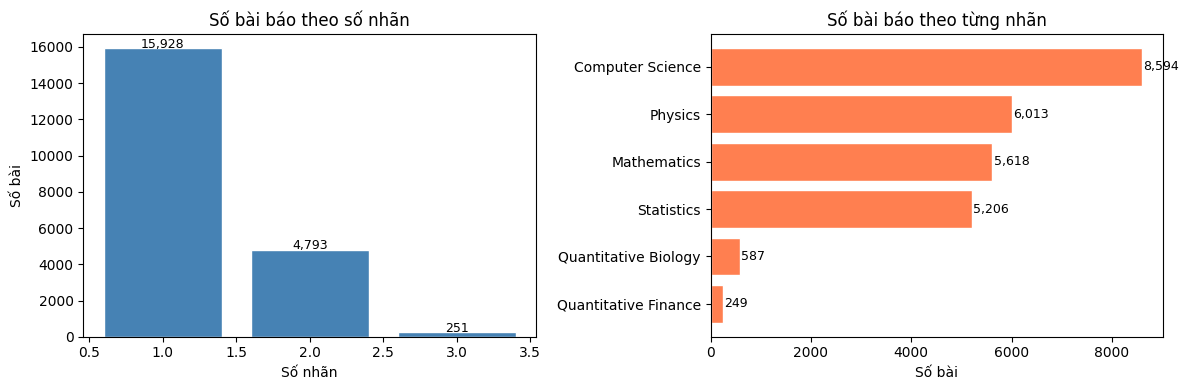

In [4]:
import matplotlib.pyplot as plt

label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

# Đếm số nhãn mỗi bài
df["num_labels"] = df[label_cols].sum(axis=1)
total = len(df)

print("=" * 52)
print("  PHÂN TÍCH ĐA NHÃN (MULTI-LABEL)")
print("=" * 52)
print(f"{'Số nhãn':<12} {'Số bài':>8} {'Tỉ lệ':>10}  Biểu đồ")
print("-" * 52)

dist = df["num_labels"].value_counts().sort_index()
for n, count in dist.items():
    bar = "█" * int(count / total * 40)
    print(f"  {n} nhãn   {count:>8,}  {count/total*100:>8.1f}%  {bar}")

print("-" * 52)
print(f"  Trung bình : {df['num_labels'].mean():.2f} nhãn/bài")
print(f"  Tối đa     : {int(df['num_labels'].max())} nhãn/bài")
print(f"  Bài 0 nhãn : {int(dist.get(0, 0)):,} bài  (không thuộc nhãn nào)")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ cột: số bài theo số nhãn
axes[0].bar(dist.index, dist.values, color="steelblue", edgecolor="white")
axes[0].set_title("Số bài báo theo số nhãn")
axes[0].set_xlabel("Số nhãn")
axes[0].set_ylabel("Số bài")
for x, y in zip(dist.index, dist.values):
    axes[0].text(x, y + 30, f"{y:,}", ha="center", fontsize=9)

# Biểu đồ cột ngang: số bài theo từng nhãn
label_counts = df[label_cols].sum().sort_values()
axes[1].barh(label_counts.index, label_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Số bài báo theo từng nhãn")
axes[1].set_xlabel("Số bài")
for i, v in enumerate(label_counts.values):
    axes[1].text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


  MA TRẬN TƯƠNG QUAN GIỮA CÁC NHÃN
                      Computer Science  Physics  Mathematics  Statistics  Quantitative Biology  Quantitative Finance
Computer Science                 1.000   -0.423       -0.311       0.084                -0.121                -0.081
Physics                         -0.423    1.000       -0.307      -0.329                -0.108                -0.069
Mathematics                     -0.311   -0.307        1.000      -0.095                -0.103                -0.065
Statistics                       0.084   -0.329       -0.095       1.000                -0.024                -0.035
Quantitative Biology            -0.121   -0.108       -0.103      -0.024                 1.000                -0.008
Quantitative Finance            -0.081   -0.069       -0.065      -0.035                -0.008                 1.000


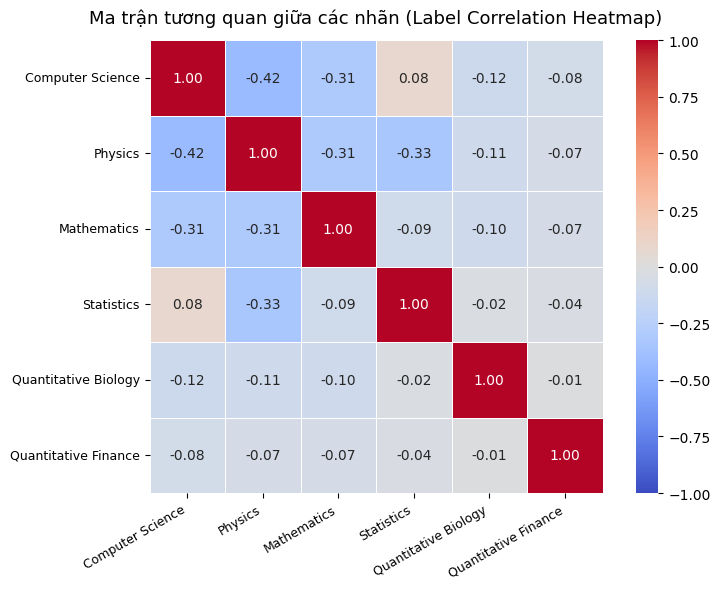


--- Top các cặp nhãn có tương quan mạnh nhất ---
Nhãn A                       Nhãn B                       Tương quan
----------------------------------------------------------------------
Computer Science             Physics                      -0.423  (ngược chiều)
Physics                      Statistics                   -0.329  (ngược chiều)
Computer Science             Mathematics                  -0.311  (ngược chiều)
Physics                      Mathematics                  -0.307  (ngược chiều)
Computer Science             Quantitative Biology         -0.121  (ngược chiều)
Physics                      Quantitative Biology         -0.108  (ngược chiều)
Mathematics                  Quantitative Biology         -0.103  (ngược chiều)
Mathematics                  Statistics                   -0.095  (ngược chiều)
Computer Science             Statistics                   +0.084  (cùng chiều)
Computer Science             Quantitative Finance         -0.081  (ngược chiều)
Physics    

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

# Tính ma trận tương quan giữa các nhãn
corr = df[label_cols].corr()

print("=" * 52)
print("  MA TRẬN TƯƠNG QUAN GIỮA CÁC NHÃN")
print("=" * 52)
print(corr.round(3).to_string())

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title("Ma trận tương quan giữa các nhãn (Label Correlation Heatmap)", fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# Tìm các cặp nhãn có tương quan cao nhất
import itertools
pairs = []
for a, b in itertools.combinations(label_cols, 2):
    pairs.append((a, b, corr.loc[a, b]))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("\n--- Top các cặp nhãn có tương quan mạnh nhất ---")
print(f"{'Nhãn A':<28} {'Nhãn B':<28} {'Tương quan':>10}")
print("-" * 70)
for a, b, r in pairs:
    direction = "cùng chiều" if r > 0 else "ngược chiều"
    print(f"{a:<28} {b:<28} {r:>+.3f}  ({direction})")


In [6]:
# ============================================================
#  TÍNH ĐỘ DÀI CỘT TITLE VÀ ABSTRACT
# ============================================================

# Số ký tự
df["title_char_len"]    = df["TITLE"].str.len()
df["abstract_char_len"] = df["ABSTRACT"].str.len()

# Số từ (tách theo khoảng trắng)
df["title_word_len"]    = df["TITLE"].str.split().str.len()
df["abstract_word_len"] = df["ABSTRACT"].str.split().str.len()

cols_info = {
    "TITLE – số ký tự"    : "title_char_len",
    "TITLE – số từ"       : "title_word_len",
    "ABSTRACT – số ký tự" : "abstract_char_len",
    "ABSTRACT – số từ"    : "abstract_word_len",
}

print("=" * 68)
print("  ĐỘ DÀI CỘT TITLE VÀ ABSTRACT")
print("=" * 68)
print(f"{'Chỉ số':<24} {'Min':>7} {'Max':>7} {'Mean':>8} {'Median':>8} {'Std':>8}")
print("-" * 68)
for label, col in cols_info.items():
    s = df[col]
    print(f"{label:<24} {s.min():>7,} {s.max():>7,} {s.mean():>8.1f} {s.median():>8.1f} {s.std():>8.1f}")

print("\n--- Ví dụ TITLE ngắn nhất ---")
print(df.loc[df["title_word_len"].idxmin(), ["ID", "TITLE", "title_word_len"]].to_string())

print("\n--- Ví dụ TITLE dài nhất ---")
print(df.loc[df["title_word_len"].idxmax(), ["ID", "TITLE", "title_word_len"]].to_string())

print("\n--- Ví dụ ABSTRACT ngắn nhất ---")
row_short = df.loc[df["abstract_word_len"].idxmin()]
print(f"ID: {row_short['ID']}  |  Số từ: {row_short['abstract_word_len']}")
print(f"Nội dung: {row_short['ABSTRACT'][:200]}")

print("\n--- Ví dụ ABSTRACT dài nhất ---")
row_long = df.loc[df["abstract_word_len"].idxmax()]
print(f"ID: {row_long['ID']}  |  Số từ: {row_long['abstract_word_len']}")
print(f"Nội dung (200 ký tự đầu): {row_long['ABSTRACT'][:200]}")


  ĐỘ DÀI CỘT TITLE VÀ ABSTRACT
Chỉ số                       Min     Max     Mean   Median      Std
--------------------------------------------------------------------
TITLE – số ký tự               7     239     72.9     71.0     26.1
TITLE – số từ                  1      40      9.5      9.0      3.6
ABSTRACT – số ký tự            7   2,761   1009.1    989.0    408.6
ABSTRACT – số từ               1     449    148.4    145.0     60.8

--- Ví dụ TITLE ngắn nhất ---
ID                      704
TITLE             Gamorithm
title_word_len            1

--- Ví dụ TITLE dài nhất ---
ID                                                              986
TITLE             A Galactic Cosmic Ray Electron Intensity Incre...
title_word_len                                                   40

--- Ví dụ ABSTRACT ngắn nhất ---
ID: 16395  |  Số từ: 1
Nội dung:   Yes.


--- Ví dụ ABSTRACT dài nhất ---
ID: 19446  |  Số từ: 449
Nội dung (200 ký tự đầu):   Topological Data Analysis (tda) is a recent and fa

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9284\3361662626.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box1.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9284\3361662626.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box2.boxplot(


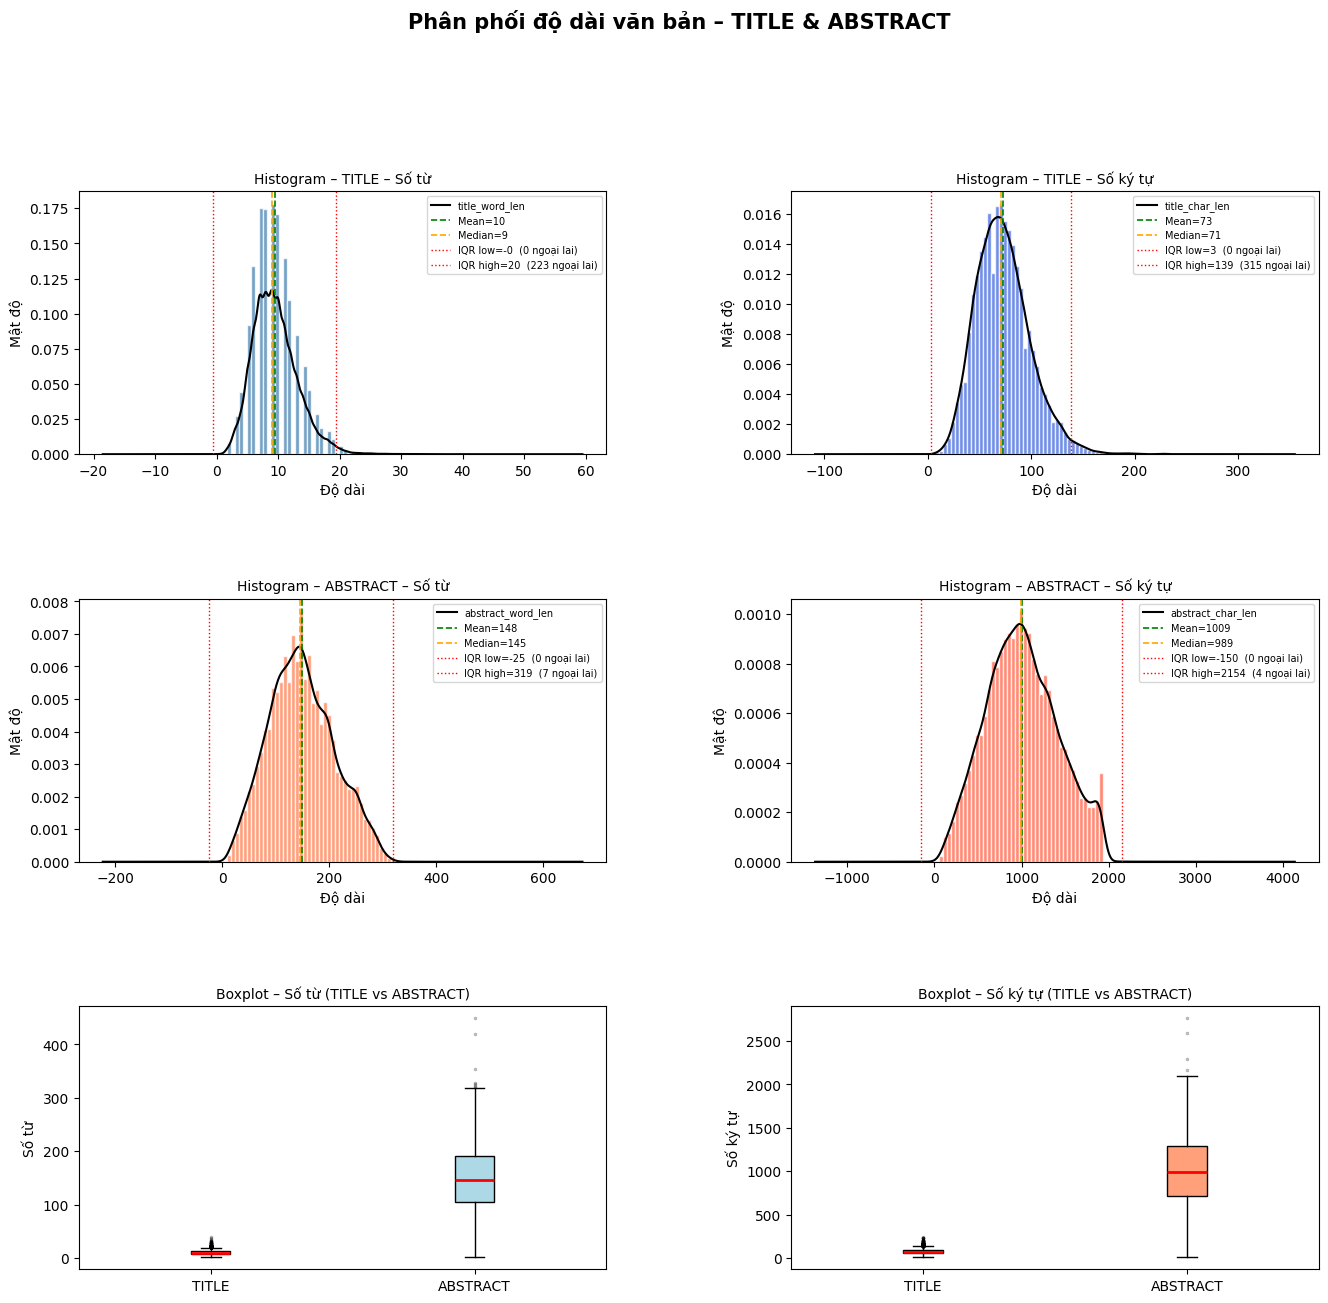


--- Tóm tắt ngoại lai (IQR × 1.5) ---
Cột                           Q1      Q3     IQR    Lower    Upper  Ngoại lai thấp  Ngoại lai cao
-----------------------------------------------------------------------------------------------
TITLE – Số từ                  7      12       5       -0       20               0            223
TITLE – Số ký tự              54      88      34        3      139               0            315
ABSTRACT – Số từ             104     190      86      -25      319               0              7
ABSTRACT – Số ký tự          714    1290     576     -150     2154               0              4


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Phân phối độ dài văn bản – TITLE & ABSTRACT", fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

metrics = [
    ("title_word_len",    "TITLE – Số từ",        "steelblue"),
    ("title_char_len",    "TITLE – Số ký tự",      "royalblue"),
    ("abstract_word_len", "ABSTRACT – Số từ",      "coral"),
    ("abstract_char_len", "ABSTRACT – Số ký tự",   "tomato"),
]

# Hàng 0–1: Histogram + KDE
for idx, (col, title, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    data = df[col]
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor="white", density=True)
    data.plot.kde(ax=ax, color="black", linewidth=1.5)

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers_low  = (data < low).sum()
    outliers_high = (data > high).sum()

    ax.axvline(data.mean(),   color="green",  linestyle="--", linewidth=1.2, label=f"Mean={data.mean():.0f}")
    ax.axvline(data.median(), color="orange", linestyle="--", linewidth=1.2, label=f"Median={data.median():.0f}")
    ax.axvline(low,  color="red", linestyle=":",  linewidth=1.0, label=f"IQR low={low:.0f}  ({outliers_low} ngoại lai)")
    ax.axvline(high, color="red", linestyle=":",  linewidth=1.0, label=f"IQR high={high:.0f}  ({outliers_high} ngoại lai)")

    ax.set_title(f"Histogram – {title}", fontsize=10)
    ax.set_xlabel("Độ dài")
    ax.set_ylabel("Mật độ")
    ax.legend(fontsize=7)

# Hàng 2: Boxplot so sánh TITLE và ABSTRACT (số từ & số ký tự)
ax_box1 = fig.add_subplot(gs[2, 0])
ax_box1.boxplot(
    [df["title_word_len"], df["abstract_word_len"]],
    labels=["TITLE", "ABSTRACT"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", color="gray", alpha=0.3, markersize=3),
)
ax_box1.set_title("Boxplot – Số từ (TITLE vs ABSTRACT)", fontsize=10)
ax_box1.set_ylabel("Số từ")

ax_box2 = fig.add_subplot(gs[2, 1])
ax_box2.boxplot(
    [df["title_char_len"], df["abstract_char_len"]],
    labels=["TITLE", "ABSTRACT"],
    patch_artist=True,
    boxprops=dict(facecolor="lightsalmon"),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", color="gray", alpha=0.3, markersize=3),
)
ax_box2.set_title("Boxplot – Số ký tự (TITLE vs ABSTRACT)", fontsize=10)
ax_box2.set_ylabel("Số ký tự")

plt.show()

# Tóm tắt ngoại lai theo IQR
print("\n--- Tóm tắt ngoại lai (IQR × 1.5) ---")
print(f"{'Cột':<24} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Lower':>8} {'Upper':>8} {'Ngoại lai thấp':>15} {'Ngoại lai cao':>14}")
print("-" * 95)
for col, title, _ in metrics:
    data = df[col]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    ol = (data < low).sum()
    oh = (data > high).sum()
    print(f"{title:<24} {q1:>7.0f} {q3:>7.0f} {iqr:>7.0f} {low:>8.0f} {high:>8.0f} {ol:>15,} {oh:>14,}")


  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH
Chuyên ngành               Số bài  Title (từ)  Title (ký tự)  Abstract (từ)  Abstract (ký tự)
--------------------------------------------------------------------------------
Computer Science            8,594         9.0           69.9          159.1            1081.9
Physics                     6,013        10.7           80.7          161.4            1096.2
Mathematics                 5,618         9.0           68.2          113.7             769.8
Statistics                  5,206         8.9           70.5          155.6            1068.4
Quantitative Biology          587        10.6           81.8          177.7            1232.2
Quantitative Finance          249         9.7           73.0          140.6             946.0


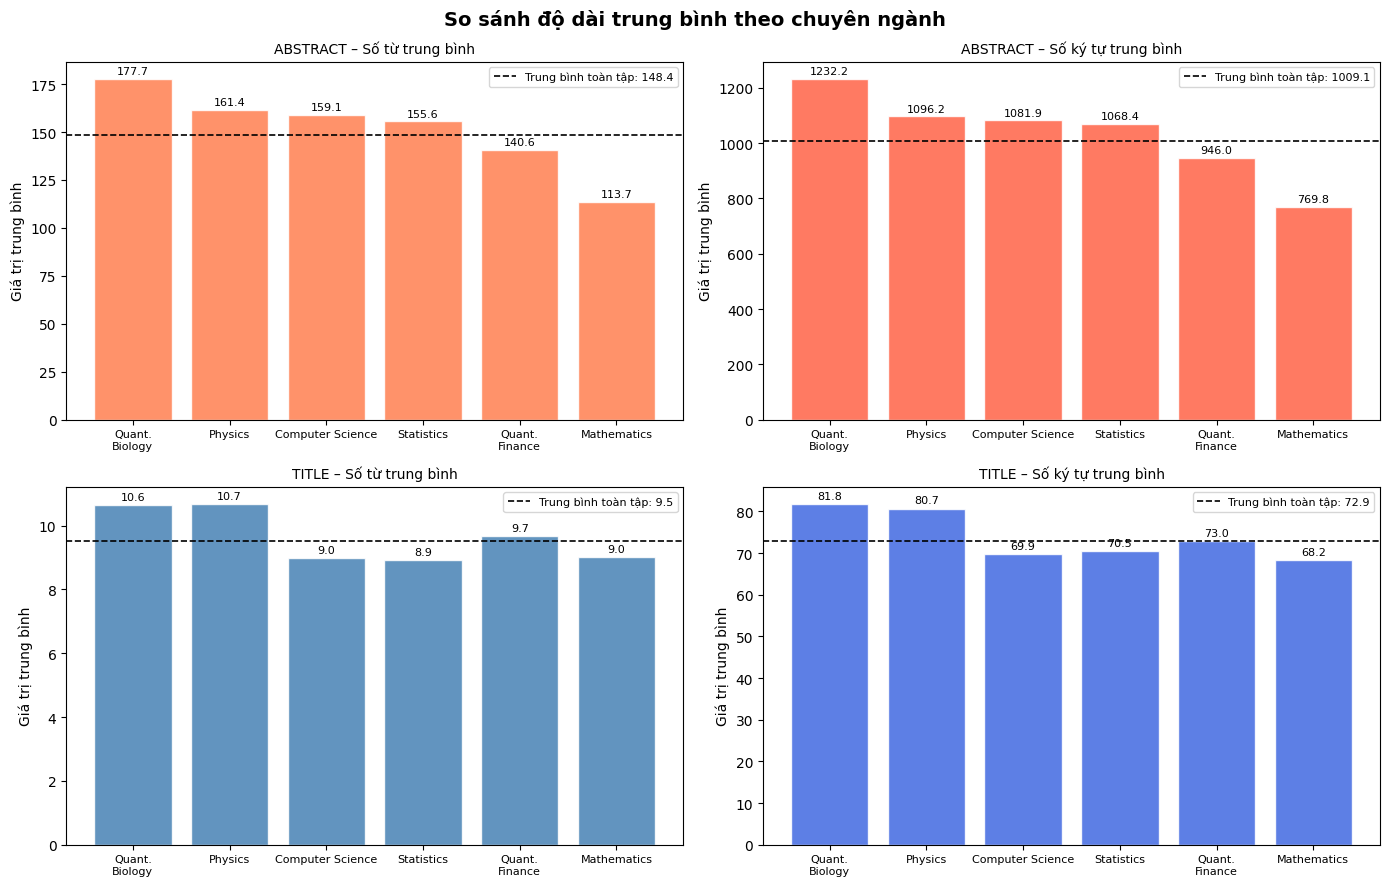


--- Nhận xét ---
Abstract dài nhất (số từ) : Quantitative Biology (177.7 từ/bài)
Abstract ngắn nhất (số từ): Mathematics (113.7 từ/bài)
Title dài nhất  (số từ)   : Physics (10.7 từ/bài)
Title ngắn nhất (số từ)   : Statistics (8.9 từ/bài)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

# Đảm bảo các cột độ dài đã tồn tại
if "abstract_word_len" not in df.columns:
    df["title_char_len"]    = df["TITLE"].str.len()
    df["abstract_char_len"] = df["ABSTRACT"].str.len()
    df["title_word_len"]    = df["TITLE"].str.split().str.len()
    df["abstract_word_len"] = df["ABSTRACT"].str.split().str.len()

# ============================================================
#  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH
# ============================================================
print("=" * 80)
print("  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH")
print("=" * 80)
print(f"{'Chuyên ngành':<25} {'Số bài':>7} "
      f"{'Title (từ)':>11} {'Title (ký tự)':>14} "
      f"{'Abstract (từ)':>14} {'Abstract (ký tự)':>17}")
print("-" * 80)

summary = []
for lbl in label_cols:
    sub = df[df[lbl] == 1]
    summary.append({
        "label"       : lbl,
        "n"           : len(sub),
        "title_words" : sub["title_word_len"].mean(),
        "title_chars" : sub["title_char_len"].mean(),
        "abs_words"   : sub["abstract_word_len"].mean(),
        "abs_chars"   : sub["abstract_char_len"].mean(),
    })
    print(f"{lbl:<25} {len(sub):>7,} "
          f"{sub['title_word_len'].mean():>11.1f} {sub['title_char_len'].mean():>14.1f} "
          f"{sub['abstract_word_len'].mean():>14.1f} {sub['abstract_char_len'].mean():>17.1f}")

# --- Vẽ biểu đồ ---
labels_sorted = [s["label"] for s in sorted(summary, key=lambda x: x["abs_words"], reverse=True)]
abs_words  = [next(s["abs_words"]  for s in summary if s["label"] == l) for l in labels_sorted]
abs_chars  = [next(s["abs_chars"]  for s in summary if s["label"] == l) for l in labels_sorted]
title_words = [next(s["title_words"] for s in summary if s["label"] == l) for l in labels_sorted]
title_chars = [next(s["title_chars"] for s in summary if s["label"] == l) for l in labels_sorted]

x = np.arange(len(labels_sorted))
short_labels = [l.replace("Quantitative ", "Quant.\n") for l in labels_sorted]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("So sánh độ dài trung bình theo chuyên ngành", fontsize=14, fontweight="bold")

datasets = [
    (axes[0, 0], abs_words,   "ABSTRACT – Số từ trung bình",       "coral"),
    (axes[0, 1], abs_chars,   "ABSTRACT – Số ký tự trung bình",    "tomato"),
    (axes[1, 0], title_words, "TITLE – Số từ trung bình",          "steelblue"),
    (axes[1, 1], title_chars, "TITLE – Số ký tự trung bình",       "royalblue"),
]

for ax, values, title, color in datasets:
    bars = ax.bar(x, values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_ylabel("Giá trị trung bình")
    # Đường trung bình toàn tập
    if "ABSTRACT" in title and "từ" in title:
        overall_val = df["abstract_word_len"].mean()
    elif "ABSTRACT" in title:
        overall_val = df["abstract_char_len"].mean()
    elif "TITLE" in title and "từ" in title:
        overall_val = df["title_word_len"].mean()
    else:
        overall_val = df["title_char_len"].mean()

    ax.axhline(overall_val, color="black", linestyle="--", linewidth=1.2,
               label=f"Trung bình toàn tập: {overall_val:.1f}")
    ax.legend(fontsize=8)
    for bar_rect, val in zip(bars, values):
        ax.text(bar_rect.get_x() + bar_rect.get_width() / 2,
                bar_rect.get_height() + overall_val * 0.01,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Nhận xét nổi bật
print("\n--- Nhận xét ---")
max_abs = max(summary, key=lambda x: x["abs_words"])
min_abs = min(summary, key=lambda x: x["abs_words"])
max_title = max(summary, key=lambda x: x["title_words"])
min_title = min(summary, key=lambda x: x["title_words"])
print(f"Abstract dài nhất (số từ) : {max_abs['label']} ({max_abs['abs_words']:.1f} từ/bài)")
print(f"Abstract ngắn nhất (số từ): {min_abs['label']} ({min_abs['abs_words']:.1f} từ/bài)")
print(f"Title dài nhất  (số từ)   : {max_title['label']} ({max_title['title_words']:.1f} từ/bài)")
print(f"Title ngắn nhất (số từ)   : {min_title['label']} ({min_title['title_words']:.1f} từ/bài)")


Đang tạo WordCloud tổng thể...


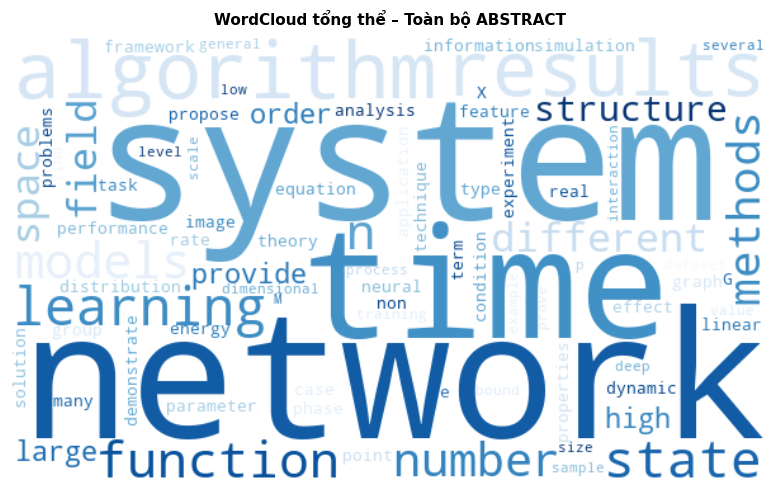

Đang tạo WordCloud theo từng nhãn...


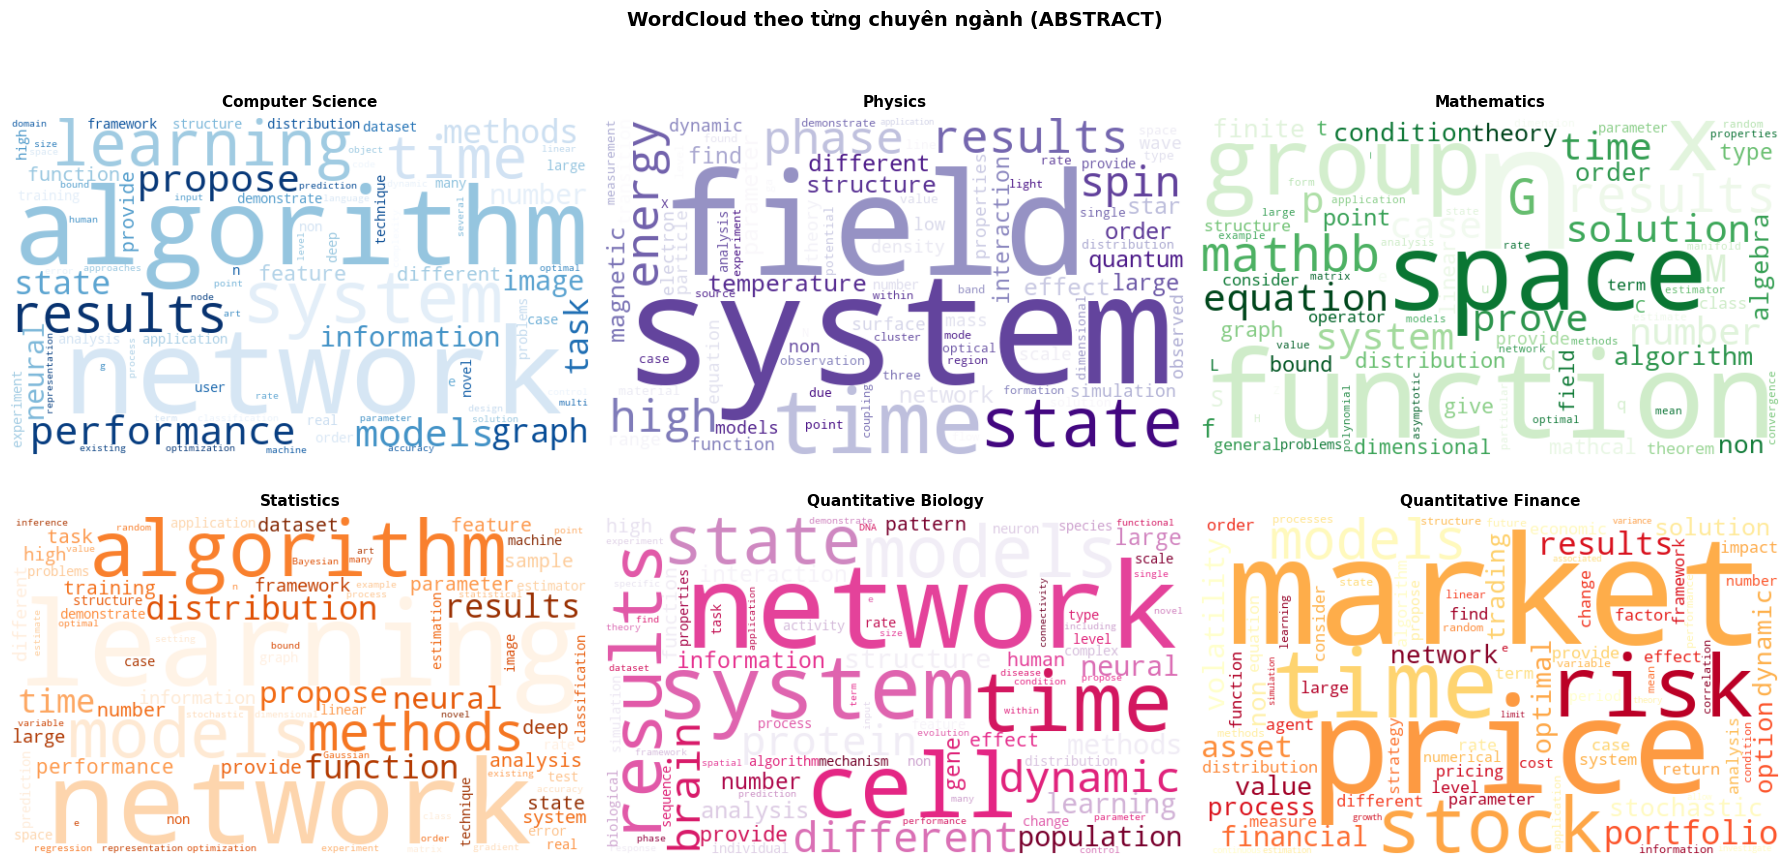

✓ Hoàn thành WordCloud – Bước 1 EDA đã hoàn tất!


In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

STOPWORDS_EXTRA = set(STOPWORDS) | {
    "using", "based", "model", "method", "paper", "show", "result",
    "proposed", "approach", "data", "problem", "two", "one", "also",
    "new", "used", "study", "present", "use", "via", "well", "known",
    "given", "may", "thus", "let", "set", "first", "work"
}

def make_wordcloud(text, title, ax, colormap="viridis"):
    wc = WordCloud(
        width=600, height=350,
        background_color="white",
        stopwords=STOPWORDS_EXTRA,
        max_words=80,
        colormap=colormap,
        collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

# ── 1. WordCloud TỔNG THỂ ──────────────────────────────────
print("Đang tạo WordCloud tổng thể...")
all_text = " ".join(df["ABSTRACT"].dropna().tolist())

fig, ax = plt.subplots(figsize=(14, 5))
make_wordcloud(all_text, "WordCloud tổng thể – Toàn bộ ABSTRACT", ax, colormap="Blues_r")
plt.tight_layout()
plt.show()

# ── 2. WordCloud THEO TỪNG NHÃN ────────────────────────────
print("Đang tạo WordCloud theo từng nhãn...")

palette = ["Blues_r", "Purples_r", "Greens_r", "Oranges_r", "PuRd_r", "YlOrRd_r"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("WordCloud theo từng chuyên ngành (ABSTRACT)", fontsize=14, fontweight="bold", y=1.01)

for ax, lbl, cmap in zip(axes.flatten(), label_cols, palette):
    text = " ".join(df[df[lbl] == 1]["ABSTRACT"].dropna().tolist())
    make_wordcloud(text, lbl, ax, colormap=cmap)

plt.tight_layout()
plt.show()
print("✓ Hoàn thành WordCloud – Bước 1 EDA đã hoàn tất!")


In [10]:
import sys, os
sys.path.insert(0, r"d:\day1\src")

from modules.preprocessing import combine_and_clean, LABEL_COLS, clean_text

# ============================================================
#  BƯỚC 2.1 & 2.2 – GHÉP VÀ LÀM SẠCH VĂN BẢN
#  (Dynamic Pipeline – cấu hình linh hoạt qua tham số)
# ============================================================

# --- Cấu hình pipeline (thay đổi tuỳ thí nghiệm) -----------
PIPELINE_CONFIG = dict(
    remove_stopwords = True,   # Bật/tắt loại stopwords
    remove_numbers   = True,   # Bật/tắt xóa số
    remove_latex     = True,   # Bật/tắt xóa ký hiệu LaTeX
    min_word_len     = 3,      # Độ dài từ tối thiểu giữ lại
)
print("=== Cấu hình Pipeline ===")
for k, v in PIPELINE_CONFIG.items():
    print(f"  {k:<20} = {v}")

df_clean = combine_and_clean(df, **PIPELINE_CONFIG)

print("\n" + "=" * 62)
print("  BƯỚC 2 – TIỀN XỬ LÝ VĂN BẢN")
print("=" * 62)

# Kiểm tra kết quả ghép
print(f"\n[2.1] Ghép TITLE + ABSTRACT → cột 'text'")
print(f"  Ví dụ (ID={df_clean['ID'].iloc[0]}):")
print(f"  TITLE   : {df_clean['TITLE'].iloc[0]}")
print(f"  text    : {df_clean['text'].iloc[0][:120]}...")

# Kiểm tra kết quả làm sạch
print(f"\n[2.2] Làm sạch → cột 'text_clean'  (config: {PIPELINE_CONFIG})")
print(f"  text_clean: {df_clean['text_clean'].iloc[0][:120]}...")

# Thống kê độ dài sau làm sạch
df_clean["clean_word_len"] = df_clean["text_clean"].str.split().str.len()

print(f"\n--- Thống kê độ dài text_clean (số từ sau làm sạch) ---")
print(f"  Min    : {df_clean['clean_word_len'].min()}")
print(f"  Max    : {df_clean['clean_word_len'].max()}")
print(f"  Mean   : {df_clean['clean_word_len'].mean():.1f}")
print(f"  Median : {df_clean['clean_word_len'].median():.1f}")

# Cảnh báo bài quá ngắn sau làm sạch
too_short = df_clean[df_clean["clean_word_len"] < 10]
print(f"\n  Số bài có < 10 từ sau làm sạch : {len(too_short):,}")
if len(too_short) > 0:
    print("  → Các bài này có thể ảnh hưởng chất lượng đặc trưng.")
    print(too_short[["ID", "text_clean", "clean_word_len"]].head(3).to_string(index=False))

print(f"\n✓ df_clean shape: {df_clean.shape}")
print(f"  Các cột mới: 'text', 'text_clean', 'clean_word_len'")


=== Cấu hình Pipeline ===
  remove_stopwords     = True
  remove_numbers       = True
  remove_latex         = True
  min_word_len         = 3

  BƯỚC 2 – TIỀN XỬ LÝ VĂN BẢN

[2.1] Ghép TITLE + ABSTRACT → cột 'text'
  Ví dụ (ID=1):
  TITLE   : Reconstructing Subject-Specific Effect Maps
  text    : Reconstructing Subject-Specific Effect Maps   Predictive models allow subject-specific inference when analyzing disease
...

[2.2] Làm sạch → cột 'text_clean'  (config: {'remove_stopwords': True, 'remove_numbers': True, 'remove_latex': True, 'min_word_len': 3})
  text_clean: reconstructing subject specific effect maps predictive models allow subject specific inference analyzing disease related...

--- Thống kê độ dài text_clean (số từ sau làm sạch) ---
  Min    : 4
  Max    : 256
  Mean   : 96.5
  Median : 95.0

  Số bài có < 10 từ sau làm sạch : 5
  → Các bài này có thể ảnh hưởng chất lượng đặc trưng.
  ID                                                            text_clean  clean_word_len

In [11]:
import os
from modules.preprocessing import split_data, LABEL_COLS

# ============================================================
#  BƯỚC 2.3 – CHIA DỮ LIỆU TRAIN / VAL (80/20)
# ============================================================

train_df, val_df = split_data(df_clean, test_size=0.2, random_state=42)

total = len(df_clean)
print("=" * 62)
print("  BƯỚC 2.3 – CHIA DỮ LIỆU TRAIN / VAL")
print("=" * 62)
print(f"\n  Tổng mẫu   : {total:,}")
print(f"  Train set  : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)")
print(f"  Val set    : {len(val_df):,}  ({len(val_df)/total*100:.1f}%)")

# Kiểm tra phân phối nhãn sau khi chia
print(f"\n--- Phân phối nhãn (tỉ lệ %) –– Train vs Val ---")
print(f"{'Nhãn':<25} {'Train %':>9} {'Val %':>9}  {'Chênh lệch':>11}")
print("-" * 58)
for lbl in LABEL_COLS:
    t_pct = train_df[lbl].mean() * 100
    v_pct = val_df[lbl].mean() * 100
    diff  = abs(t_pct - v_pct)
    flag  = " ⚠" if diff > 1.0 else ""
    print(f"{lbl:<25} {t_pct:>8.1f}% {v_pct:>8.1f}%  {diff:>10.2f}%{flag}")

# Kiểm tra phân phối số nhãn/bài
print(f"\n--- Phân phối số nhãn/bài ---")
print(f"{'Số nhãn':<10} {'Train':>8} {'Val':>8}")
print("-" * 28)
for n in sorted(df_clean[LABEL_COLS].sum(axis=1).unique()):
    t_n = (train_df[LABEL_COLS].sum(axis=1) == n).sum()
    v_n = (val_df[LABEL_COLS].sum(axis=1) == n).sum()
    print(f"  {int(n)} nhãn  {t_n:>8,} {v_n:>8,}")

# Lưu ra file CSV
os.makedirs(r"d:\day1\src\data", exist_ok=True)
train_df.to_csv(r"d:\day1\src\data\train_split.csv", index=False)
val_df.to_csv(r"d:\day1\src\data\val_split.csv",   index=False)

print(f"\n✓ Đã lưu:")
print(f"   d:\\day1\\src\\data\\train_split.csv  ({len(train_df):,} dòng)")
print(f"   d:\\day1\\src\\data\\val_split.csv    ({len(val_df):,} dòng)")
print(f"\n✓ Bước 2 hoàn tất – Sẵn sàng cho Bước 3 (Trích xuất đặc trưng)")


  BƯỚC 2.3 – CHIA DỮ LIỆU TRAIN / VAL

  Tổng mẫu   : 20,972
  Train set  : 16,777  (80.0%)
  Val set    : 4,195  (20.0%)

--- Phân phối nhãn (tỉ lệ %) –– Train vs Val ---
Nhãn                        Train %     Val %   Chênh lệch
----------------------------------------------------------
Computer Science              40.9%     41.3%        0.39%
Physics                       28.7%     28.7%        0.04%
Mathematics                   27.0%     26.0%        0.95%
Statistics                    24.8%     24.8%        0.04%
Quantitative Biology           2.8%      2.7%        0.13%
Quantitative Finance           1.1%      1.5%        0.45%

--- Phân phối số nhãn/bài ---
Số nhãn       Train      Val
----------------------------
  1 nhãn    12,742    3,186
  2 nhãn     3,826      967
  3 nhãn       209       42

✓ Đã lưu:
   d:\day1\src\data\train_split.csv  (16,777 dòng)
   d:\day1\src\data\val_split.csv    (4,195 dòng)

✓ Bước 2 hoàn tất – Sẵn sàng cho Bước 3 (Trích xuất đặc trưng)


In [12]:
import sys, os, numpy as np
sys.path.insert(0, r"d:\day1\src")

from modules.feature_extraction import build_tfidf, FEATURES_DIR

FEATURES_SAVE_DIR = r"d:\day1\src\features"

# ============================================================
#  BƯỚC 3.1 – TRÍCH XUẤT ĐẶC TRƯNG TF-IDF
# ============================================================

print("=" * 62)
print("  BƯỚC 3.1 – TF-IDF")
print("=" * 62)

vectorizer, X_train_tfidf, X_val_tfidf = build_tfidf(
    train_texts=train_df["text_clean"],
    val_texts=val_df["text_clean"],
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    save_dir=FEATURES_SAVE_DIR,
)

print(f"\n  Vocabulary size : {len(vectorizer.vocabulary_):,}")
print(f"  X_train shape   : {X_train_tfidf.shape}")
print(f"  X_val   shape   : {X_val_tfidf.shape}")
print(f"  Kiểu dữ liệu    : {type(X_train_tfidf).__name__} (sparse matrix)")
print(f"  Dung lượng train: {X_train_tfidf.data.nbytes / 1024**2:.1f} MB (non-zero values)")

# Top 20 từ quan trọng nhất theo idf
import pandas as pd
feature_names = vectorizer.get_feature_names_out()
idf_scores    = vectorizer.idf_
top20 = pd.Series(idf_scores, index=feature_names).sort_values(ascending=False).head(20)
print(f"\n  Top 20 term theo IDF cao nhất (hiếm gặp nhất):")
print("  " + ", ".join(top20.index.tolist()))

print(f"\n✓ TF-IDF hoàn tất – file lưu tại {FEATURES_SAVE_DIR}")


  BƯỚC 3.1 – TF-IDF
[TF-IDF] Đã lưu → d:\day1\src\features/tfidf_train.npz  &  tfidf_val.npz

  Vocabulary size : 50,000
  X_train shape   : (16777, 50000)
  X_val   shape   : (4195, 50000)
  Kiểu dữ liệu    : csr_matrix (sparse matrix)
  Dung lượng train: 11.2 MB (non-zero values)

  Top 20 term theo IDF cao nhất (hiếm gặp nhất):
  ybmggao, ybrh, fsa, zero knowledge, bof, boat, frg, functions involution, functions quantum, fundamental constants, word equations, sliced wasserstein, bloch equations, block bootstrap, skin lesions, skeletal data, sketch sketch, blue waters, bluff, slew

✓ TF-IDF hoàn tất – file lưu tại d:\day1\src\features


In [13]:
from modules.feature_extraction import build_bert_embeddings

# ============================================================
#  BƯỚC 3.2 – TRÍCH XUẤT ĐẶC TRƯNG BERT
#  (SentenceTransformer 'all-MiniLM-L6-v2')
#
#  ⚠ Lưu ý: cell này encode ~20,000 văn bản → ~5-15 phút
#           tùy GPU/CPU. Chỉ cần chạy 1 lần, kết quả lưu .npy
# ============================================================

print("=" * 62)
print("  BƯỚC 3.2 – BERT EMBEDDINGS")
print("=" * 62)

X_train_bert, X_val_bert = build_bert_embeddings(
    train_texts=train_df["text_clean"],
    val_texts=val_df["text_clean"],
    model_name="all-MiniLM-L6-v2",
    batch_size=64,
    save_dir=FEATURES_SAVE_DIR,
)

print(f"\n  X_train_bert shape : {X_train_bert.shape}  (n_samples × 384 dims)")
print(f"  X_val_bert   shape : {X_val_bert.shape}")
print(f"  Kiểu dữ liệu       : {X_train_bert.dtype}")
print(f"  Dung lượng train   : {X_train_bert.nbytes / 1024**2:.1f} MB")

# Kiểm tra nhanh: L2 norm của vài vector (BERT chuẩn hóa về ~1)
import numpy as np
norms = np.linalg.norm(X_train_bert[:5], axis=1)
print(f"\n  L2-norm 5 vector đầu: {norms.round(4)}")

print(f"\n✓ BERT hoàn tất – file lưu tại {FEATURES_SAVE_DIR}")
print(f"   bert_train.npy : {X_train_bert.shape[0]:,} × {X_train_bert.shape[1]}")
print(f"   bert_val.npy   : {X_val_bert.shape[0]:,} × {X_val_bert.shape[1]}")
print(f"\n✓ Bước 3 hoàn tất – Sẵn sàng cho Bước 4 (Huấn luyện mô hình)")


  BƯỚC 3.2 – BERT EMBEDDINGS


d:\day1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[BERT] Đang load model 'all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7198.18it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Encoding train (16,777 mẫu)...


Batches: 100%|██████████| 263/263 [04:48<00:00,  1.10s/it]


[BERT] Encoding val (4,195 mẫu)...


Batches: 100%|██████████| 66/66 [01:12<00:00,  1.10s/it]

[BERT] Đã lưu → d:\day1\src\features/bert_train.npy  &  bert_val.npy

  X_train_bert shape : (16777, 384)  (n_samples × 384 dims)
  X_val_bert   shape : (4195, 384)
  Kiểu dữ liệu       : float32
  Dung lượng train   : 24.6 MB

  L2-norm 5 vector đầu: [1. 1. 1. 1. 1.]

✓ BERT hoàn tất – file lưu tại d:\day1\src\features
   bert_train.npy : 16,777 × 384
   bert_val.npy   : 4,195 × 384

✓ Bước 3 hoàn tất – Sẵn sàng cho Bước 4 (Huấn luyện mô hình)


In [14]:
import sys, os
sys.path.insert(0, r"d:\day1\src")

import numpy as np
from modules.preprocessing import LABEL_COLS
from modules.models import build_models, train_models, save_models

MODELS_DIR = r"d:\day1\src\models"

# Label matrix
y_train = train_df[LABEL_COLS].values   # (16777, 6)
y_val   = val_df[LABEL_COLS].values     # (4195, 6)

# ============================================================
#  BƯỚC 4.1 – HUẤN LUYỆN TRÊN TF-IDF
#  (Dynamic config – thay đổi tham số tuỳ thí nghiệm)
# ============================================================

MODEL_CONFIG_TFIDF = dict(
    feature_type = "tfidf",   # → dùng ComplementNB
    lr_C         = 1.0,       # Chính quy hóa LogisticRegression
    lr_max_iter  = 1000,
    nb_alpha     = 0.1,       # Làm trơn ComplementNB
    svc_C        = 1.0,       # Chính quy hóa LinearSVC
    svc_max_iter = 2000,
)

print("=== Cấu hình mô hình (TF-IDF) ===")
for k, v in MODEL_CONFIG_TFIDF.items():
    print(f"  {k:<15} = {v}")

print("\n" + "=" * 62)
print("  BƯỚC 4.1 – HUẤN LUYỆN TRÊN TF-IDF")
print("=" * 62)
print(f"  X_train_tfidf : {X_train_tfidf.shape}  |  y_train : {y_train.shape}")

models_tfidf  = build_models(**MODEL_CONFIG_TFIDF)
trained_tfidf = train_models(models_tfidf, X_train_tfidf, y_train)

print("\n--- Lưu mô hình ---")
save_models(trained_tfidf, MODELS_DIR, prefix="tfidf_")

print(f"\n✓ Bước 4.1 hoàn tất – {len(trained_tfidf)} mô hình TF-IDF đã huấn luyện")


=== Cấu hình mô hình (TF-IDF) ===
  feature_type    = tfidf
  lr_C            = 1.0
  lr_max_iter     = 1000
  nb_alpha        = 0.1
  svc_C           = 1.0
  svc_max_iter    = 2000

  BƯỚC 4.1 – HUẤN LUYỆN TRÊN TF-IDF
  X_train_tfidf : (16777, 50000)  |  y_train : (16777, 6)
  Đang huấn luyện LogisticRegression... ✓
  Đang huấn luyện NaiveBayes... ✓
  Đang huấn luyện LinearSVC... ✓

--- Lưu mô hình ---
  Đã lưu: d:\day1\src\models\tfidf_LogisticRegression.joblib
  Đã lưu: d:\day1\src\models\tfidf_NaiveBayes.joblib
  Đã lưu: d:\day1\src\models\tfidf_LinearSVC.joblib

✓ Bước 4.1 hoàn tất – 3 mô hình TF-IDF đã huấn luyện


In [15]:
from modules.models import build_models, train_models, save_models

# ============================================================
#  BƯỚC 4.2 – HUẤN LUYỆN TRÊN BERT
#  (Dynamic config – thay đổi tham số tuỳ thí nghiệm)
# ============================================================

MODEL_CONFIG_BERT = dict(
    feature_type = "bert",    # → dùng GaussianNB (hỗ trợ giá trị âm)
    lr_C         = 1.0,
    lr_max_iter  = 1000,
    svc_C        = 1.0,
    svc_max_iter = 2000,
)

print("=== Cấu hình mô hình (BERT) ===")
for k, v in MODEL_CONFIG_BERT.items():
    print(f"  {k:<15} = {v}")

print("\n" + "=" * 62)
print("  BƯỚC 4.2 – HUẤN LUYỆN TRÊN BERT")
print("=" * 62)
print(f"  X_train_bert : {X_train_bert.shape}  |  y_train : {y_train.shape}")

models_bert  = build_models(**MODEL_CONFIG_BERT)
trained_bert = train_models(models_bert, X_train_bert, y_train)

print("\n--- Lưu mô hình ---")
save_models(trained_bert, MODELS_DIR, prefix="bert_")

print(f"\n✓ Bước 4.2 hoàn tất – {len(trained_bert)} mô hình BERT đã huấn luyện")
print(f"\n✓ Bước 4 hoàn tất – Sẵn sàng cho Bước 5 (Đánh giá)")


=== Cấu hình mô hình (BERT) ===
  feature_type    = bert
  lr_C            = 1.0
  lr_max_iter     = 1000
  svc_C           = 1.0
  svc_max_iter    = 2000

  BƯỚC 4.2 – HUẤN LUYỆN TRÊN BERT
  X_train_bert : (16777, 384)  |  y_train : (16777, 6)
  Đang huấn luyện LogisticRegression... ✓
  Đang huấn luyện NaiveBayes... ✓
  Đang huấn luyện LinearSVC... ✓

--- Lưu mô hình ---
  Đã lưu: d:\day1\src\models\bert_LogisticRegression.joblib
  Đã lưu: d:\day1\src\models\bert_NaiveBayes.joblib
  Đã lưu: d:\day1\src\models\bert_LinearSVC.joblib

✓ Bước 4.2 hoàn tất – 3 mô hình BERT đã huấn luyện

✓ Bước 4 hoàn tất – Sẵn sàng cho Bước 5 (Đánh giá)


In [16]:
from modules.evaluation import evaluate_model, print_results_table, print_per_label_report
from modules.preprocessing import LABEL_COLS

# ============================================================
#  BƯỚC 5 – ĐÁNH GIÁ VÀ SO SÁNH TẤT CẢ MÔ HÌNH
# ============================================================

all_results = {}

print("=" * 62)
print("  BƯỚC 5 – ĐÁNH GIÁ MÔ HÌNH (Validation Set)")
print("=" * 62)

# --- TF-IDF ---
print("\n--- TF-IDF ---")
for name, model in trained_tfidf.items():
    m = evaluate_model(model, X_val_tfidf, y_val, LABEL_COLS)
    all_results[f"TF-IDF|{name}"] = m
    print(f"  {name:<22}  Micro-F1 = {m['micro_f1']:.4f}  |  Macro-F1 = {m['macro_f1']:.4f}")

# --- BERT ---
print("\n--- BERT ---")
for name, model in trained_bert.items():
    m = evaluate_model(model, X_val_bert, y_val, LABEL_COLS)
    all_results[f"BERT|{name}"] = m
    print(f"  {name:<22}  Micro-F1 = {m['micro_f1']:.4f}  |  Macro-F1 = {m['macro_f1']:.4f}")

# --- Bảng tổng hợp ---
print()
print_results_table(all_results)


  BƯỚC 5 – ĐÁNH GIÁ MÔ HÌNH (Validation Set)

--- TF-IDF ---
  LogisticRegression      Micro-F1 = 0.8168  |  Macro-F1 = 0.5671
  NaiveBayes              Micro-F1 = 0.8193  |  Macro-F1 = 0.7364
  LinearSVC               Micro-F1 = 0.8254  |  Macro-F1 = 0.7071

--- BERT ---
  LogisticRegression      Micro-F1 = 0.8149  |  Macro-F1 = 0.6801
  NaiveBayes              Micro-F1 = 0.7831  |  Macro-F1 = 0.6897
  LinearSVC               Micro-F1 = 0.8189  |  Macro-F1 = 0.7131

  BẢNG SO SÁNH KẾT QUẢ (Validation Set)
  #    Feature    Model                    Micro-F1   Macro-F1
  ------------------------------------------------------------
  1    TF-IDF     LinearSVC                  0.8254     0.7071  ← best
  2    TF-IDF     NaiveBayes                 0.8193     0.7364
  3    BERT       LinearSVC                  0.8189     0.7131
  4    TF-IDF     LogisticRegression         0.8168     0.5671
  5    BERT       LogisticRegression         0.8149     0.6801
  6    BERT       NaiveBayes           

=== Chi tiết mô hình tốt nhất: TF-IDF|LinearSVC (Micro-F1=0.8254) ===

  Nhãn                          Precision   Recall   F1-score   Support
  --------------------------------------------------------------------
  Computer Science                  0.830    0.851      0.840     1,732
  Physics                           0.946    0.865      0.903     1,204
  Mathematics                       0.853    0.791      0.821     1,092
  Statistics                        0.786    0.740      0.762     1,040
  Quantitative Biology              0.700    0.248      0.366       113
  Quantitative Finance              0.962    0.385      0.549        65
  --------------------------------------------------------------------
  micro avg                                            0.825   (Micro-F1)
  macro avg                                            0.707   (Macro-F1)


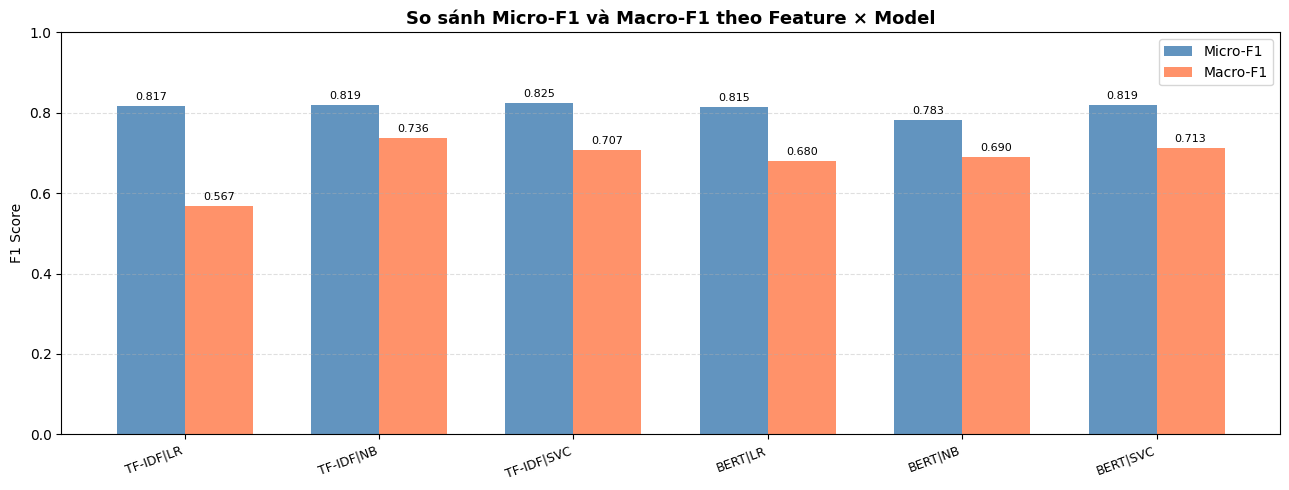


--- Nhận xét so sánh ---
  TF-IDF best : TF-IDF|LinearSVC  →  Micro-F1 = 0.8254
  BERT   best : BERT|LinearSVC   →  Micro-F1 = 0.8189
  ➜ TF-IDF tốt hơn BERT +0.0065 Micro-F1

✓ Bước 5 hoàn tất – Sẵn sàng Bước 6 (Packaging)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
#  BƯỚC 5.2 – BÁO CÁO CHI TIẾT THEO TỪNG NHÃN
# ============================================================

# --- Tìm mô hình tốt nhất (Micro-F1) ---
best_key   = max(all_results, key=lambda k: all_results[k]["micro_f1"])
best_micro = all_results[best_key]["micro_f1"]

print(f"=== Chi tiết mô hình tốt nhất: {best_key} (Micro-F1={best_micro:.4f}) ===\n")
print_per_label_report(all_results[best_key], LABEL_COLS)

# --- Biểu đồ so sánh Micro-F1 và Macro-F1 ---
keys      = list(all_results.keys())
micro_f1s = [all_results[k]["micro_f1"] for k in keys]
macro_f1s = [all_results[k]["macro_f1"] for k in keys]
short_keys = [k.replace("LogisticRegression", "LR")
               .replace("NaiveBayes", "NB")
               .replace("LinearSVC", "SVC") for k in keys]

x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, micro_f1s, width, label="Micro-F1", color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + width/2, macro_f1s, width, label="Macro-F1", color="coral",      alpha=0.85)

ax.set_title("So sánh Micro-F1 và Macro-F1 theo Feature × Model", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(short_keys, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# --- Nhận xét so sánh TF-IDF vs BERT ---
tfidf_best = max(
    {k: v for k, v in all_results.items() if k.startswith("TF-IDF")},
    key=lambda k: all_results[k]["micro_f1"]
)
bert_best = max(
    {k: v for k, v in all_results.items() if k.startswith("BERT")},
    key=lambda k: all_results[k]["micro_f1"]
)

print(f"\n--- Nhận xét so sánh ---")
print(f"  TF-IDF best : {tfidf_best}  →  Micro-F1 = {all_results[tfidf_best]['micro_f1']:.4f}")
print(f"  BERT   best : {bert_best}   →  Micro-F1 = {all_results[bert_best]['micro_f1']:.4f}")
diff = all_results[bert_best]["micro_f1"] - all_results[tfidf_best]["micro_f1"]
if diff > 0:
    print(f"  ➜ BERT tốt hơn TF-IDF {diff:+.4f} Micro-F1")
else:
    print(f"  ➜ TF-IDF tốt hơn BERT {-diff:+.4f} Micro-F1")

print(f"\n✓ Bước 5 hoàn tất – Sẵn sàng Bước 6 (Packaging)")
